# Quick EDA

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

In [3]:
# importing the merged image and clinical data
img_clinical_data = pd.read_csv('data/merged_image_clinical_features.csv')

In [4]:
# ignore column 'Patient ID' - it is only an identifier and does not contain any useful information for our analysis
img_clinical_data_X = img_clinical_data.drop(columns=['Patient ID', 'HRD_Proxy'])
img_clinical_data_y = img_clinical_data['HRD_Proxy']

In [5]:
print(f'Number of positive samples: {img_clinical_data_y.sum() / len(img_clinical_data_y) * 100:.2f}%')

Number of positive samples: 18.35%


our dataset is imbalanced. will have to keep this in mind for modeling. 

In [7]:
# drop the highly correlated features (let's look at 0.8 as a threshold)
correlation_matrix = img_clinical_data_X.corr()
upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

# Find index of feature columns with a correlation greater than 0.8
columns_to_drop = [column for column in upper_triangle.columns if any(abs(upper_triangle[column]) > 0.8)]
# Drop those features from original dataframe
corr_thresh = img_clinical_data_X.drop(columns=columns_to_drop)
print(f'dropped {len(columns_to_drop)}; {len(corr_thresh.columns)} feats left')


dropped 382; 147 feats left


In [16]:
# create dir for plots
results_path = Path('results')
results_path.mkdir(exist_ok=True)

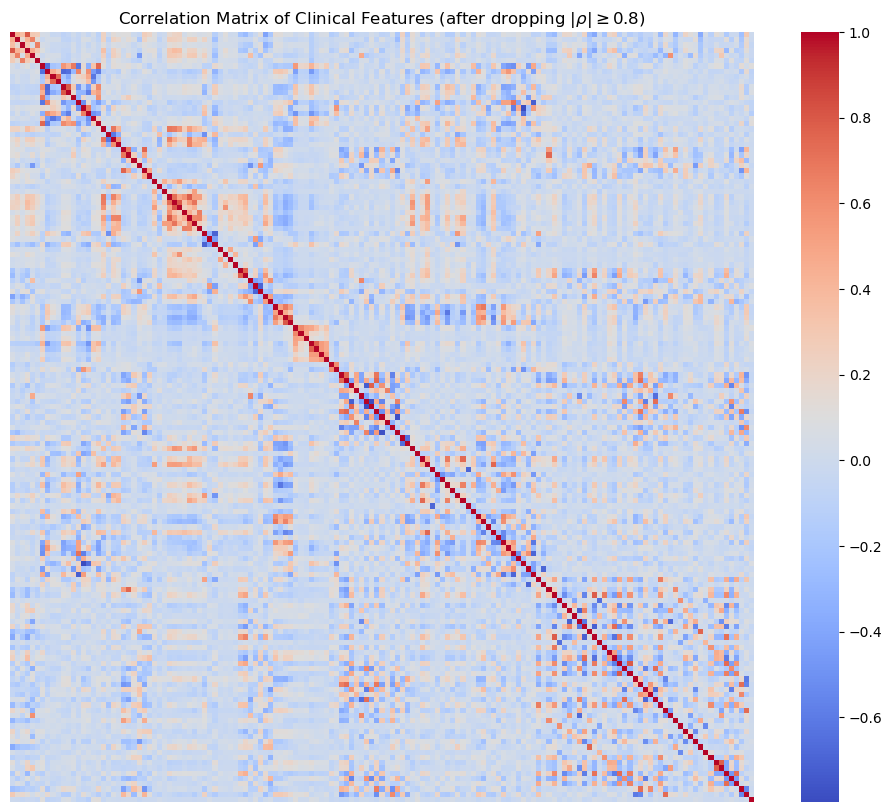

In [22]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_thresh.corr(), xticklabels=False, yticklabels=False, cmap='coolwarm', fmt='.2f')
plt.title(r'Correlation Matrix of Clinical Features (after dropping |$\rho| \geq 0.8$)')
fig = plt.gcf()
fig.savefig('results/clinical_feature_correlation_matrix.png', dpi=300, bbox_inches='tight')

/Users/ariellejoasil/opt/anaconda3/envs/py312/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/ariellejoasil/opt/anaconda3/envs/py312/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 1200x1000 with 0 Axes>

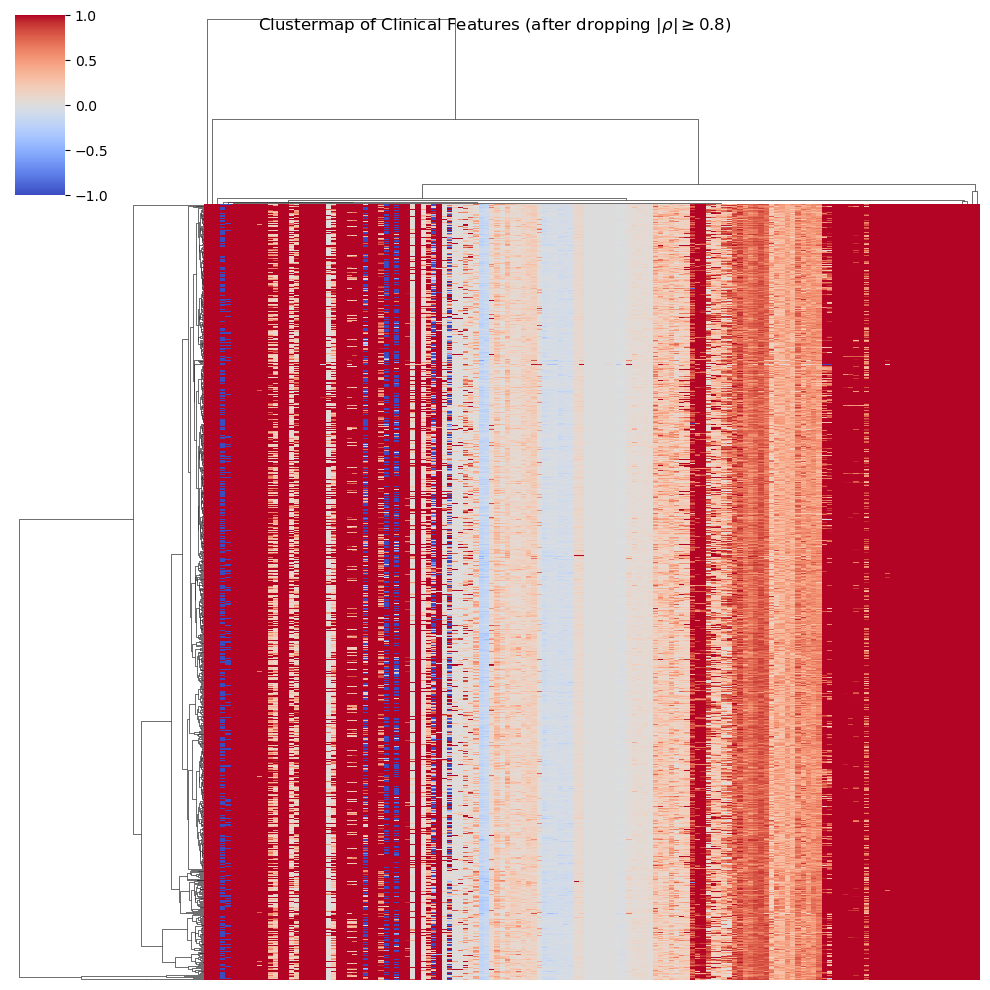

In [24]:
# create clustermap 
plt.figure(figsize=(12, 10))
g = sns.clustermap(corr_thresh, xticklabels=False, yticklabels=False, cmap='coolwarm', center=0, vmin=-1, vmax=1)
g.fig.suptitle(r'Clustermap of Clinical Features (after dropping $|\rho| \geq 0.8$)')
fig = plt.gcf()
fig.savefig('results/clinical_feature_clustermap.png', dpi=300, bbox_inches='tight')